In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem


In [2]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

### Load and combine scRNA and ATAC seq data

In [3]:
rna_path = '/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/stream_input_filtered_cells_v7.h5ad'
atac_path = '/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/adata_aggregated_peak.leiden.h5ad'

In [4]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

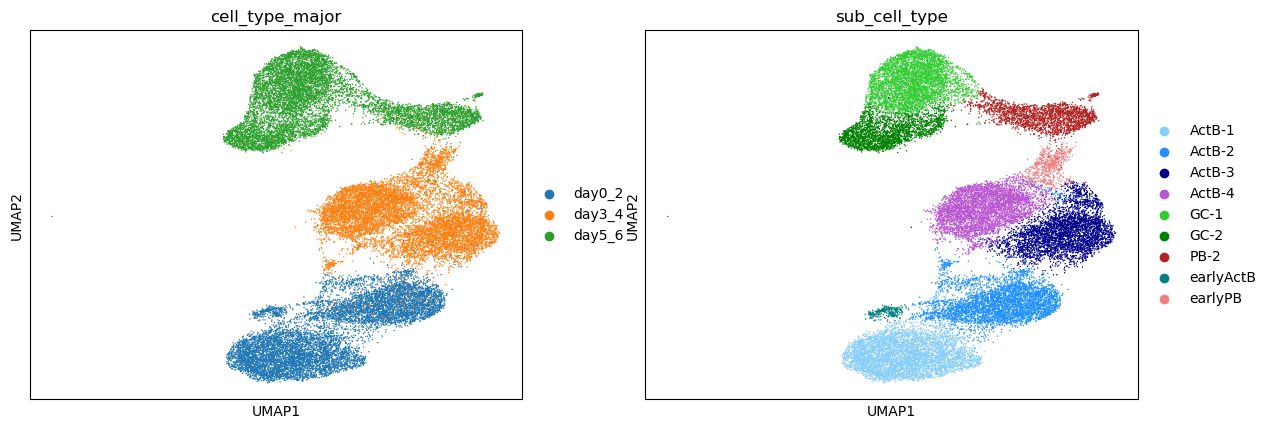

In [ ]:
sc.pl.umap(rna_adata, color=['cell_type_major', 'sub_cell_type'])

In [ ]:
rna_adata.obs['cell_type_major']

AAACAGCCAAGCCACT-3    day5_6
AAACAGCCAAGGTGCA-1    day0_2
AAACAGCCAAGTTATC-1    day0_2
AAACAGCCAATAGCCC-1    day0_2
AAACAGCCAGTTAGCC-1    day0_2
                       ...  
TTTGTTGGTTTACGTC-1    day0_2
TTTGTTGGTTTAGTCC-1    day0_2
TTTGTTGGTTTATGGG-2    day3_4
TTTGTTGGTTTCCTCC-3    day5_6
TTTGTTGGTTTGAGGC-2    day3_4
Name: cell_type_major, Length: 28494, dtype: category
Categories (3, str): ['day0_2', 'day3_4', 'day5_6']

### preprocessing

In [5]:
# make temporal info numeric
def adapt_time(x):
    if x["cell_type_major"] == "day0_2":
        return 1.5
    if x["cell_type_major"] == "day3_4":
        return 3.5
    if x["cell_type_major"] == "day5_6":
        return 5.5
    raise ValueError

rna_adata.obs["cell_type_major"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [7]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="cell_type_major")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


### Compute cost matrix

In [10]:
import networkx as nx

dfs = {}
batch_column = "cell_type_major"
unique_batches = [1.5, 3.5, 5.5]

# pair wise WOT
for i in range(len(unique_batches) - 1):
    batch1 = unique_batches[i]
    batch2 = unique_batches[i + 1]

    indices = np.where(
        (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
    )[0]
    adata_subset = rna_adata[indices]

    sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")
    G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
    assert nx.is_connected(G)

    # store the kNN graph as a dense pandas df and save it in a dict
    dfs[(batch1, batch2)] = pd.DataFrame(
        index=adata_subset.obs_names,
        columns=adata_subset.obs_names,
        data=adata_subset.obsp["connectivities"].todense().astype("float"),
    )

In [13]:
for (t1, t2) in [(1.5, 3.5), (3.5, 5.5)]:
    prob = tp0[t1, t2]

    expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)  # Index
    Gdf = dfs[(t1, t2)].loc[expected, expected].astype(float)

    prob.set_graph_xy(Gdf, t=100.0)


### Solve the temporal problem

In [14]:
# epsilon: entropic regularization strength
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)

INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9383, 9194)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(9917, 9383)].                                  


In [18]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix
T_35_55 = tp0[3.5, 5.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)
T_35_55_np = np.asarray(T_35_55)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)
T_35_55_csr = sp.csr_matrix(T_35_55_np)

sp.save_npz("/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/T_1.5_3.5.npz", T_15_35_csr)
sp.save_npz("/ocean/projects/cis240075p/cliu57/dynamic_OT/datasets/B_cell/T_3.5_5.5.npz", T_35_55_csr)

### Identify ancestor and descendants

Descendant view asks: given an early type A, where does it go?

Ancestor view asks: given a late type B, where did it come from?

In [19]:
order_celltypes = rna_adata.obs["sub_cell_type"].cat.categories.tolist()
order_celltypes

['ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'GC-1',
 'GC-2',
 'PB-2',
 'earlyActB',
 'earlyPB']

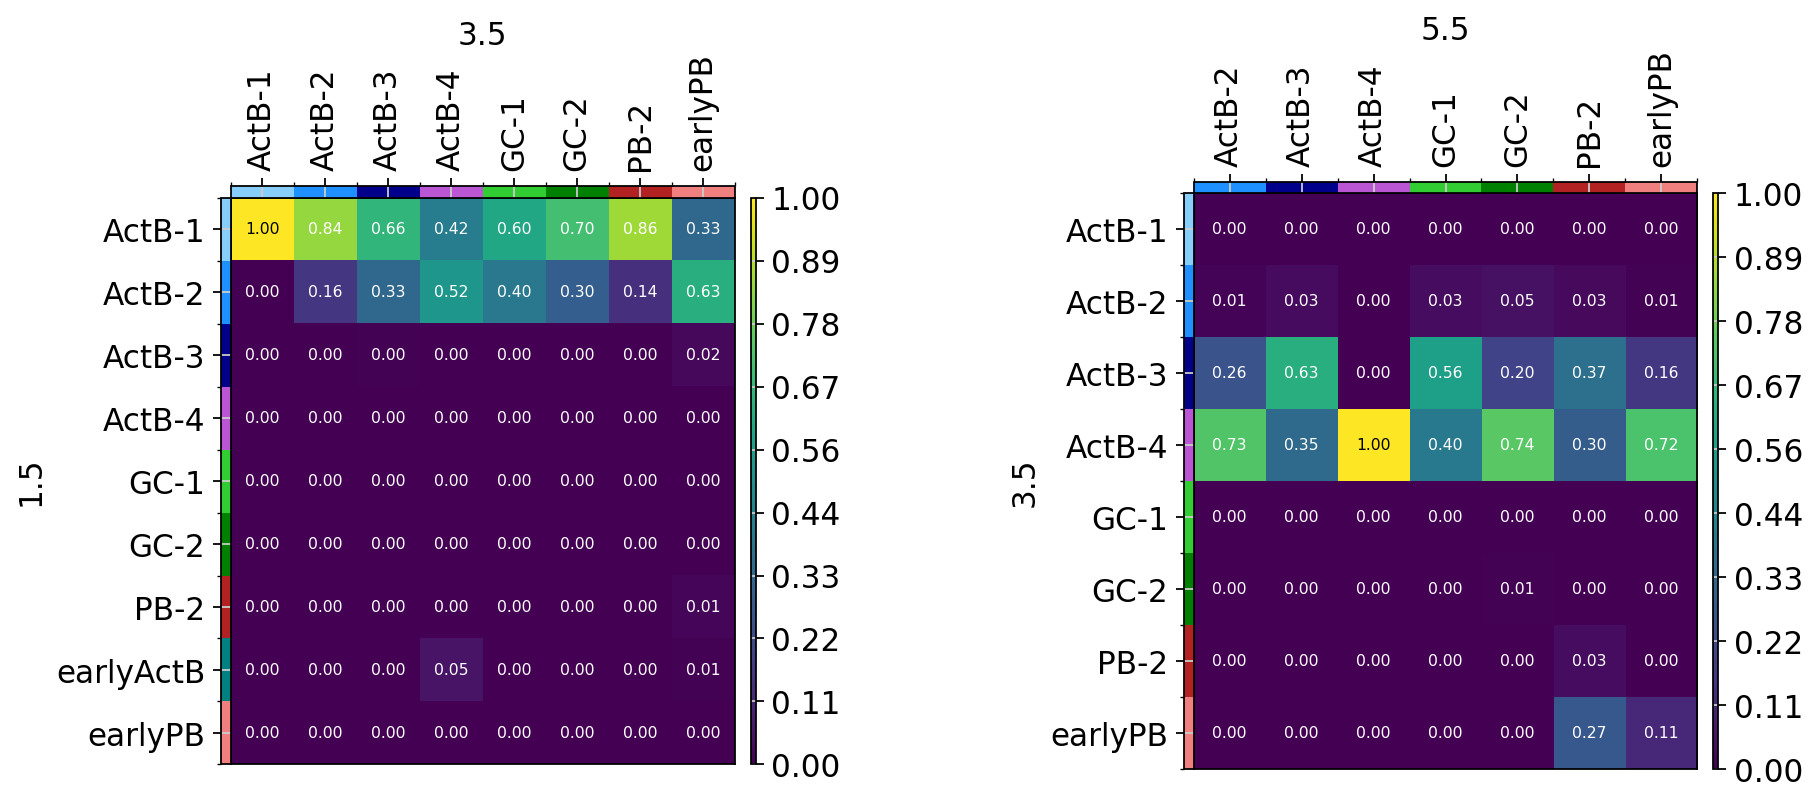

In [20]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_3.5_5.5_large",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5_large",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5_large",
)


fig.subplots_adjust(wspace=0.8)

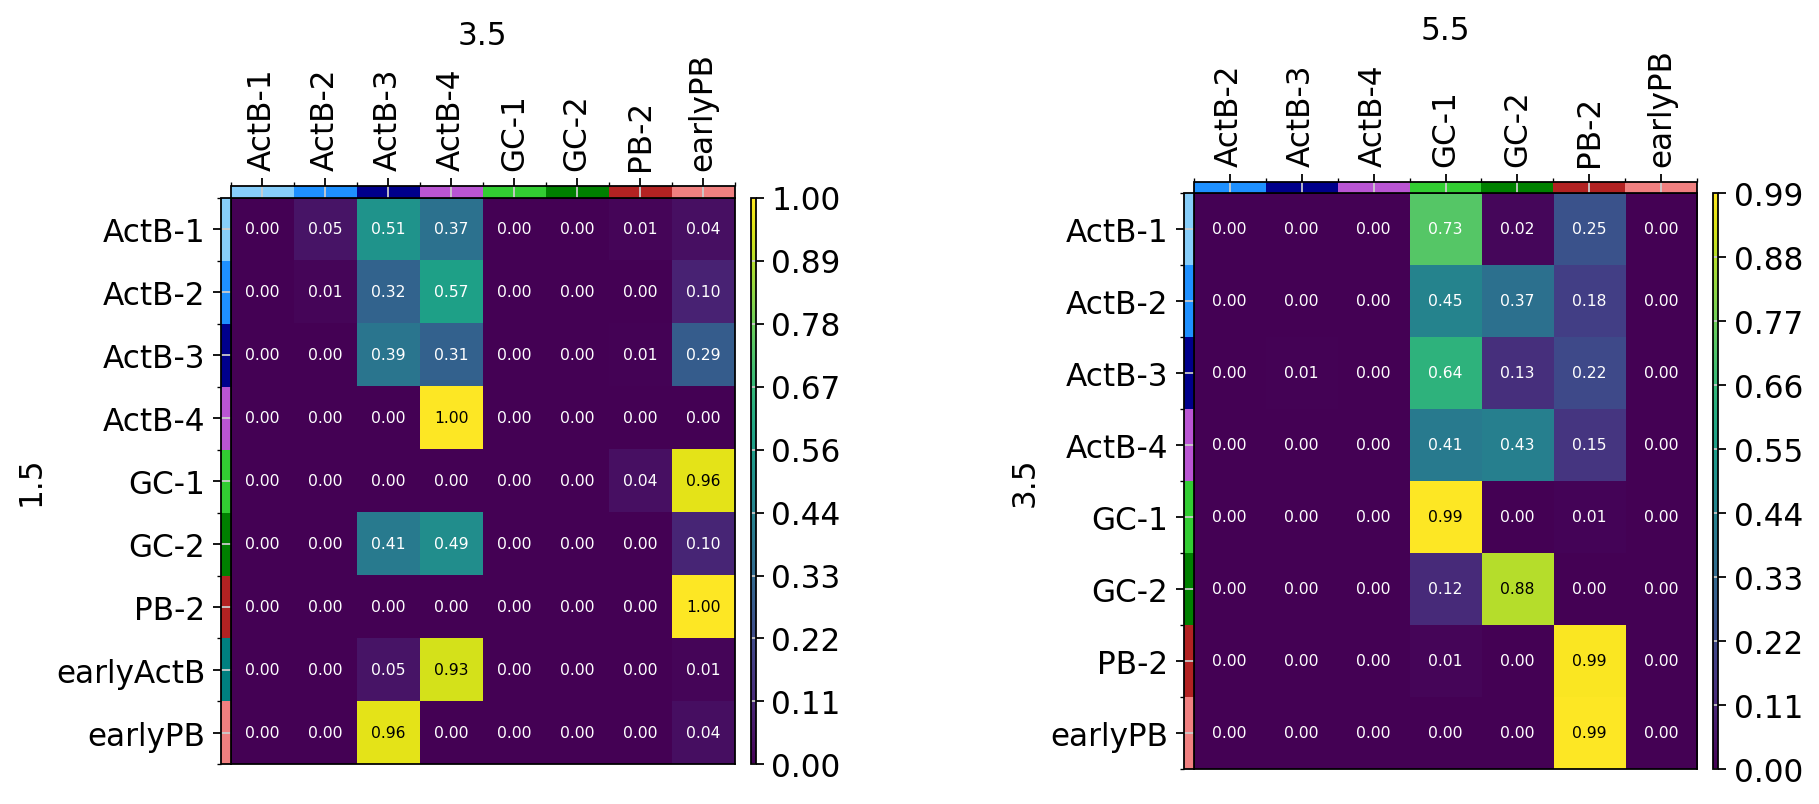

In [21]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_1.5_3.5",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_3.5_5.5",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5",
)


fig.subplots_adjust(wspace=0.8)

### visualizing ancestors and descendants

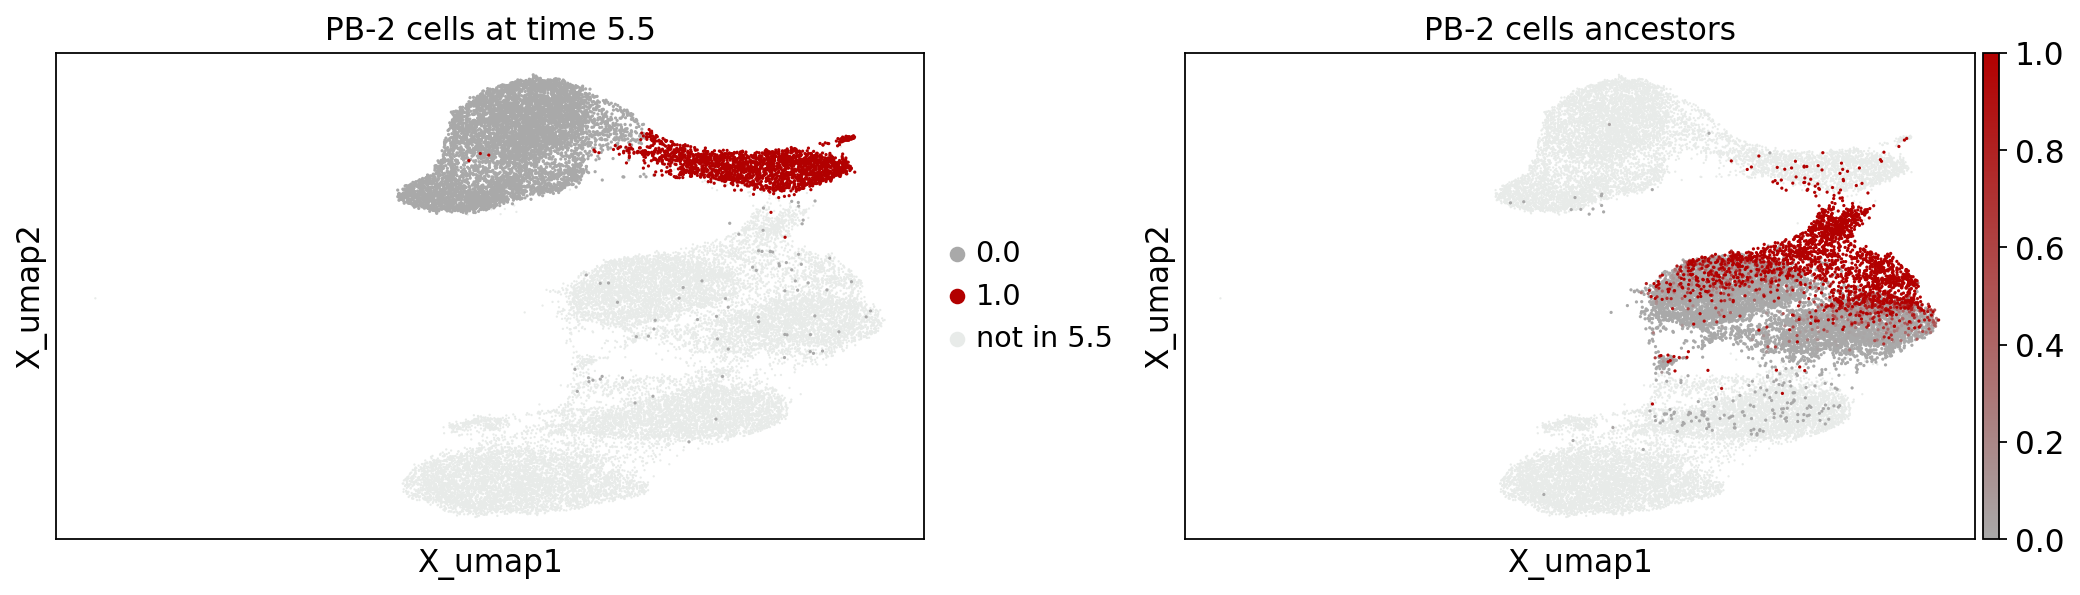

In [27]:
tp0.pull(source=3.5, target=5.5, data="sub_cell_type", subset="PB-2")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[5.5],
    basis="X_umap",
    ax=axes[0],
    title=["PB-2 cells at time 5.5"],
)

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[1],
    title=["PB-2 cells ancestors"],
)

fig.subplots_adjust(wspace=0.3)

In [28]:
tp0.sankey(
    source=3.5,
    target=5.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

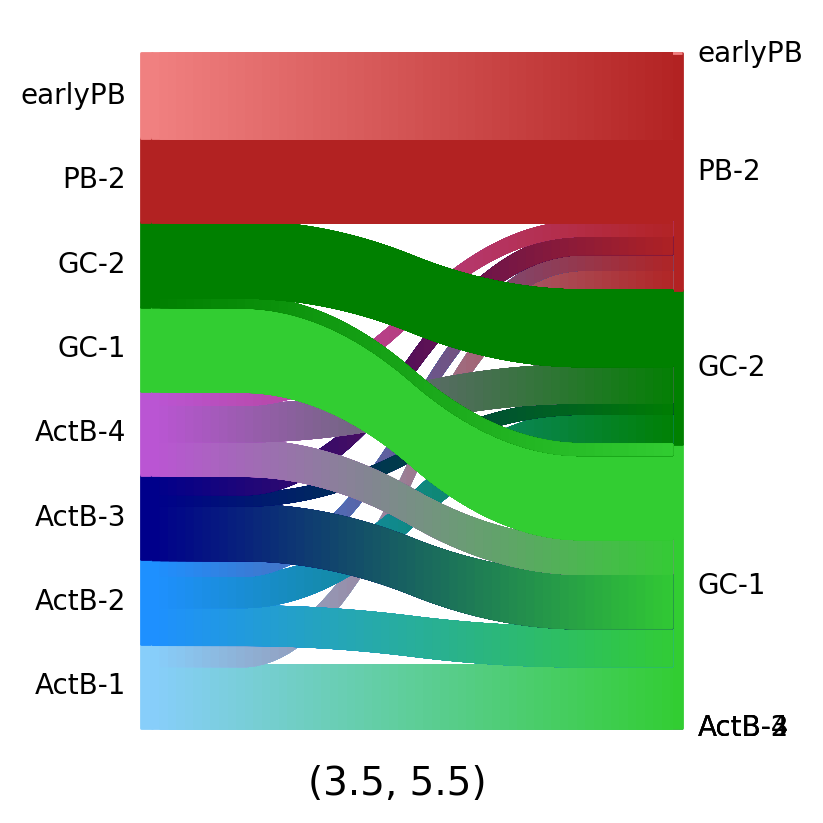

In [31]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

In [32]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"sub_cell_type": order_celltypes},
    target_groups={"sub_cell_type": order_celltypes},
    threshold=0.05,
    order_annotations=order_celltypes[::-1],
    normalize=True,
)

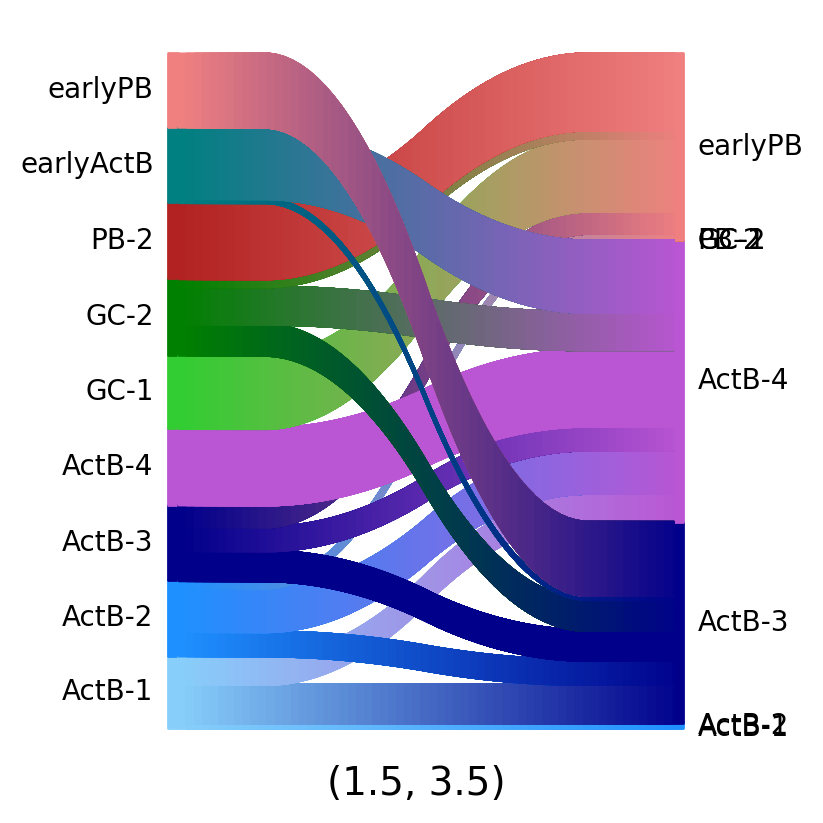

In [33]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)